# Actividad 2.2: Aprendizaje Supervisado
## Dataset: Breast Cancer (Ljubljana, Yugoslavia)

**Integrantes del equipo:**
*   Abigail Pérez García | A01736815
*   Alvaro Alberto Cruz Jiménez | A01737453
*   Fernando Maggi Llerandi | A01736935
*   Rodrigo López Guerra | A01737437

---

**Descripción del dataset:**
286 instancias, 9 atributos categóricos + 1 clase binaria (`no-recurrence-events` / `recurrence-events`).  
Distribución de clases: 201 (70.3%) vs 85 (29.7%) — clases desbalanceadas.  


## I. Selección de datos y Preprocesamiento

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score

import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import ast

In [2]:

warnings.filterwarnings('ignore')

# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv('Cancer.csv')

print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Dimensiones del dataset: (286, 10)

Primeras filas:


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,Class
0,40-49,premeno,15-19,0-2,yes,3,right,left_up,no,recurrence-events
1,50-59,ge40,15-19,0-2,no,1,right,central,no,no-recurrence-events
2,50-59,ge40,35-39,0-2,no,2,left,left_low,no,recurrence-events
3,40-49,premeno,35-39,0-2,yes,3,right,left_low,yes,no-recurrence-events
4,40-49,premeno,30-34,3-5,yes,2,left,right_up,no,recurrence-events


In [3]:
print('Tipos de datos originales:')
print(df.dtypes)
print('\nValores únicos por columna:')
for col in df.columns:
    print(f'  {col}: {sorted(df[col].dropna().unique().tolist())}')

Tipos de datos originales:
age              str
menopause        str
tumor-size       str
inv-nodes        str
node-caps        str
deg-malig      int64
breast           str
breast-quad      str
irradiat         str
Class            str
dtype: object

Valores únicos por columna:
  age: ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
  menopause: ['ge40', 'lt40', 'premeno']
  tumor-size: ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54']
  inv-nodes: ['0-2', '12-14', '15-17', '24-26', '3-5', '6-8', '9-11']
  node-caps: ['?', 'no', 'yes']
  deg-malig: [1, 2, 3]
  breast: ['left', 'right']
  breast-quad: ['?', 'central', 'left_low', 'left_up', 'right_low', 'right_up']
  irradiat: ['no', 'yes']
  Class: ['no-recurrence-events', 'recurrence-events']


In [4]:
print('Valores faltantes por columna:')
print(df.isnull().sum())
print(f'\nTotal de instancias con al menos un valor faltante: {df.isnull().any(axis=1).sum()}')

Valores faltantes por columna:
age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiat       0
Class          0
dtype: int64

Total de instancias con al menos un valor faltante: 0


### 1.1 Manejo de valores faltantes

Según el README, los atributos `node-caps` (8 faltantes) y `breast-quad` (1 faltante) tienen valores `?`.  
Se reemplazarán los `?` por `NaN` y luego se imputará con la **moda** de cada columna, ya que todos los atributos son categóricos.


In [5]:
# Reemplazar '?' por NaN
df.replace('?', np.nan, inplace=True)

# Imputar con la moda
for col in df.columns:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f'  {col}: imputado con moda = "{moda}"')

print('\nValores faltantes tras imputación:', df.isnull().sum().sum())

  node-caps: imputado con moda = "no"
  breast-quad: imputado con moda = "left_low"

Valores faltantes tras imputación: 9


### 1.2 Transformación de atributos a numérico

Todos los atributos son categóricos. Se aplican distintas estrategias según su naturaleza:

| Atributo | Tipo | Justificación de codificación |
|---|---|---|
| `age` | **Ordinal** | Rangos etarios con orden natural → codificación ordinal |
| `menopause` | **Ordinal** | `lt40 < premeno < ge40` → codificación ordinal |
| `tumor-size` | **Ordinal** | Rangos de tamaño con orden natural → codificación ordinal |
| `inv-nodes` | **Ordinal** | Rangos de nodos invadidos con orden → codificación ordinal |
| `node-caps` | **Nominal binario** | `yes/no` → 1/0 |
| `deg-malig` | **Ordinal** | Ya es numérico (1, 2, 3), solo se convierte a int |
| `breast` | **Nominal binario** | `left/right` → 0/1 |
| `breast-quad` | **Nominal** | 5 categorías sin orden → One-Hot Encoding |
| `irradiat` | **Nominal binario** | `yes/no` → 1/0 |
| `Class` | **Target** | `no-recurrence-events` → 0, `recurrence-events` → 1 |


In [6]:
df_enc = df.copy()

# ── Ordinales con orden natural ───────────────────────────────────────────────
age_order = ['10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90-99']
df_enc['age'] = pd.Categorical(df_enc['age'], categories=age_order, ordered=True).codes

menopause_order = ['lt40','premeno','ge40']
df_enc['menopause'] = pd.Categorical(df_enc['menopause'], categories=menopause_order, ordered=True).codes

tumor_order = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59']
df_enc['tumor-size'] = pd.Categorical(df_enc['tumor-size'], categories=tumor_order, ordered=True).codes

invnodes_order = ['0-2','3-5','6-8','9-11','12-14','15-17','18-20','21-23','24-26','27-29','30-32','33-35','36-39']
df_enc['inv-nodes'] = pd.Categorical(df_enc['inv-nodes'], categories=invnodes_order, ordered=True).codes

# ── Nominales binarios ────────────────────────────────────────────────────────
df_enc['node-caps'] = df_enc['node-caps'].map({'no': 0, 'yes': 1})
df_enc['breast']    = df_enc['breast'].map({'left': 0, 'right': 1})
df_enc['irradiat']  = df_enc['irradiat'].map({'no': 0, 'yes': 1})

# ── deg-malig ya es numérico ──────────────────────────────────────────────────
df_enc['deg-malig'] = df_enc['deg-malig'].astype(int)

# ── breast-quad: One-Hot Encoding (nominal sin orden) ────────────────────────
df_enc = pd.get_dummies(df_enc, columns=['breast-quad'], drop_first=False)

# ── Variable objetivo ─────────────────────────────────────────────────────────
df_enc['Class'] = df_enc['Class'].map({'no-recurrence-events': 0, 'recurrence-events': 1})

print('Dataset preprocesado:')
print(df_enc.dtypes)
print(f'\nForma final: {df_enc.shape}')
df_enc.head()

Dataset preprocesado:
age                         int8
menopause                   int8
tumor-size                  int8
inv-nodes                   int8
node-caps                float64
deg-malig                  int64
breast                     int64
irradiat                   int64
Class                      int64
breast-quad_central         bool
breast-quad_left_low        bool
breast-quad_left_up         bool
breast-quad_right_low       bool
breast-quad_right_up        bool
dtype: object

Forma final: (286, 14)


,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,irradiat,Class,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up
0,3,1,3,0,1.0,3,1,0,1,False,False,True,False,False
1,4,2,3,0,0.0,1,1,0,0,True,False,False,False,False
2,4,2,7,0,0.0,2,0,0,1,False,True,False,False,False
3,3,1,7,0,1.0,3,1,1,0,False,True,False,False,False
4,3,1,6,1,1.0,2,0,0,1,False,False,False,False,True


### 1.3 Normalización de atributos ordinales

Los atributos ordinales (`age`, `menopause`, `tumor-size`, `inv-nodes`, `deg-malig`) tienen rangos distintos.  
Se aplica normalización **Min-Max** para llevarlos al rango [0, 1], lo que es especialmente importante para kNN (sensible a la escala de los datos).

In [7]:
# Columnas a normalizar (ordinales numéricas)
cols_normalizar = ['age', 'menopause', 'tumor-size', 'inv-nodes', 'deg-malig']

scaler = MinMaxScaler()
df_enc[cols_normalizar] = scaler.fit_transform(df_enc[cols_normalizar])

print('Estadísticas tras normalización:')
df_enc[cols_normalizar].describe().round(3)

Estadísticas tras normalización:


,age,menopause,tumor-size,inv-nodes,deg-malig
count,286.000,286.000,286.000,286.000,286.000
mean,0.533,0.713,0.488,0.066,0.524
std,0.202,0.271,0.211,0.144,0.369
min,0.000,0.000,0.000,0.000,0.000
25%,0.400,0.500,0.400,0.000,0.500
50%,0.600,0.500,0.500,0.000,0.500
75%,0.600,1.000,0.600,0.125,1.000
max,1.000,1.000,1.000,1.000,1.000


### 1.4 Separación de conjuntos (70% entrenamiento / 30% evaluación)

Se usa `stratify=y` para preservar la proporción de clases (70.3% / 29.7%) en ambos subconjuntos.

In [8]:
X = df_enc.drop(columns=['Class'])
y = df_enc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} instancias')
print(f'  Clase 0 (no-recurrence): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'  Clase 1 (recurrence):    {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'\nEvaluación: {X_test.shape[0]} instancias')
print(f'  Clase 0 (no-recurrence): {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')
print(f'  Clase 1 (recurrence):    {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')

Entrenamiento: 200 instancias
  Clase 0 (no-recurrence): 141 (70.5%)
  Clase 1 (recurrence):    59 (29.5%)

Evaluación: 86 instancias
  Clase 0 (no-recurrence): 60 (69.8%)
  Clase 1 (recurrence):    26 (30.2%)


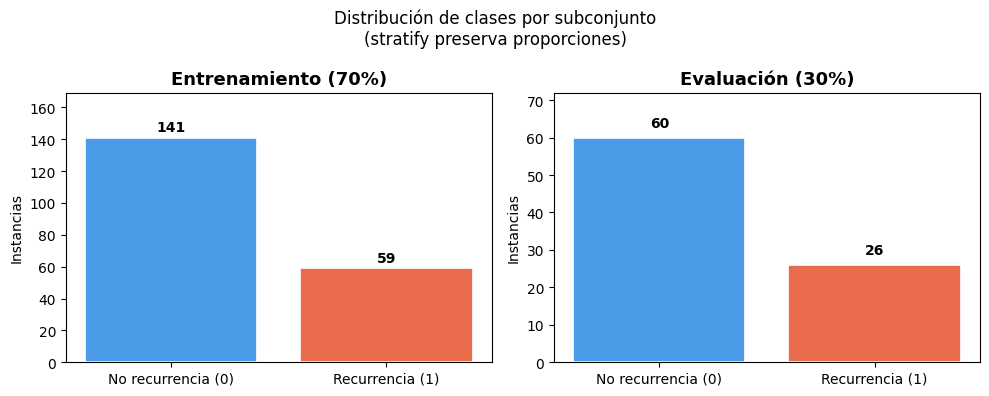

✓ La proporción ~70% / ~30% se conserva en ambos conjuntos gracias a stratify=y


In [9]:
# Gráfica de distribución de clases en ambos conjuntos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['No recurrencia (0)', 'Recurrencia (1)']
colores = ['#4C9BE8', '#E86B4C']

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), 'Entrenamiento (70%)'),
    (y_test.value_counts().sort_index(),  'Evaluación (30%)')
]):
    bars = ax.bar(labels, counts.values, color=colores, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Instancias')
    ax.set_ylim(0, counts.max() * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                ha='center', va='bottom', fontweight='bold')

fig.suptitle('Distribución de clases por subconjunto\n(stratify preserva proporciones)', fontsize=12)
plt.tight_layout()
plt.show()
print('✓ La proporción ~70% / ~30% se conserva en ambos conjuntos gracias a stratify=y')

## II. Investigación Documental: Random Forest

### ¿Cómo funciona?
Random Forest es un método de **ensamble** que construye múltiples árboles de decisión durante el entrenamiento y combina sus predicciones mediante votación mayoritaria (clasificación) o promedio (regresión). Se basa en dos principios clave:

1. **Bootstrap aggregating (Bagging):** cada árbol se entrena con una muestra aleatoria *con reemplazo* del conjunto de entrenamiento.
2. **Selección aleatoria de características:** en cada nodo de cada árbol, solo se considera un subconjunto aleatorio de `max_features` atributos para la división. Esto decorrelaciona los árboles y reduce la varianza.

El resultado es un modelo más robusto frente al sobreajuste que un único árbol de decisión.

### Tipos de datos
Maneja datos numéricos y categóricos (aunque scikit-learn requiere codificación numérica previa). Tolera bien valores atípicos y relaciones no lineales entre atributos.

### Parámetros principales (scikit-learn)
| Parámetro | Descripción | Valor por defecto |
|---|---|---|
| `n_estimators` | Número de árboles en el bosque | 100 |
| `max_depth` | Profundidad máxima de cada árbol | None (sin límite) |
| `max_features` | # atributos a considerar por nodo (`'sqrt'`, `'log2'`, int) | `'sqrt'` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | 2 |
| `min_samples_leaf` | Mínimo de muestras en una hoja | 1 |
| `criterion` | Función de impureza (`gini`, `entropy`) | `'gini'` |
| `bootstrap` | Si se usan muestras bootstrap | True |

### Tipo de modelo
Modelo de **caja negra** (no interpretable directamente), aunque proporciona métricas de importancia de características (`feature_importances_`).

### Fuentes
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
- scikit-learn documentation: https://scikit-learn.org/stable/modules/ensemble.html#forest
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly.

---
## III. Implementación de Algoritmos

### 3.1 kNN — Implementación propia (sin librerías automáticas)

La elección de la Distancia de Minkowski obedece a su naturaleza versátil, permitiendo parametrizar la geometría del espacio mediante el valor p. Esta flexibilidad es vital en el análisis de datos médicos, ya que permite ajustar el modelo para ser robusto ante valores atípicos mediante la distancia Manhattan (p=1) o realizar un análisis de proximidad estándar con la distancia Euclidiana (p=2), adaptándose así a la complejidad de las variables del dataset.

Dentro del código, las variables x1 y x2 representan los vectores de características de los pacientes, actuando como sus coordenadas en un espacio multidimensional. El parámetro p define el grado de penalización: un valor alto acentúa las diferencias marcadas en atributos individuales, mientras que un valor bajo las distribuye equitativamente. El proceso utiliza un acumulador de suma para integrar estas diferencias, resultando en una distancia final que cuantifica la similitud entre las instancias.

Como optimización técnica, se aplicó un casteo obligatorio a float y el uso de la función abs(). Estas implementaciones garantizan la estabilidad del algoritmo al prevenir errores por tipos de datos inconsistentes (como strings o nulos) y asegurar que las operaciones de potencia operen sobre bases positivas, manteniendo la coherencia de la métrica en todo el espectro del dataset de cáncer.

In [10]:
def distancia_minkowski(x1, x2, p=2):
    suma = 0

    for i in range(len(x1)):
        valor_1 = float(x1[i])
        valor_2 = float(x2[i])
        diferencia = abs(valor_1 - valor_2)
        suma += diferencia ** p

    distancia = suma ** (1 / p)
    return distancia

Este componente define el criterio final de clasificación tras identificar los k puntos más cercanos. Su función es consolidar la información de la vecindad para asignar una etiqueta definitiva a la instancia evaluada, permitiendo elegir entre un consenso simple o un sistema de pesos. Al activar el modo ponderado, el algoritmo deja de tratar a todos los vecinos por igual; de esta forma, los puntos con mayor proximidad física tienen un impacto superior en la decisión, lo que ayuda a mitigar el efecto de posibles valores atípicos que podrían sesgar el resultado en una votación simple.

Dentro del código, la variable votos funciona como un diccionario acumulador donde las llaves representan las clases detectadas y los valores almacenan la suma de sus pesos. La variable peso determina la influencia de cada vecino: en el modo simple es una constante unitaria, mientras que en el ponderado se calcula como el inverso de la distancia. Se integró una constante de estabilidad (1e-9) para prevenir errores de división entre cero en casos de coincidencia exacta, asegurando que la clase_ganadora sea siempre aquella que logre la mayor puntuación agregada bajo una lógica de selección por valor máximo.

In [11]:
def voto_mayoritario(vecinos, ponderado=False):
    votos = {}

    for distancia, clase in vecinos:
        if ponderado:
            peso = 1 / (distancia + 1e-9)
        else:
            peso = 1

        if clase not in votos:
            votos[clase] = 0

        votos[clase] += peso

    clase_ganadora = max(votos, key=votos.get)
    return clase_ganadora

Este módulo constituye el núcleo operativo del algoritmo kNN, donde se coordina el cálculo de distancias y la votación para clasificar una única muestra. Su función es transformar las mediciones numéricas de un nuevo paciente en una decisión categórica basada en la similitud con casos históricos previamente almacenados.

En el flujo del código, el ciclo **`for`** recorre exhaustivamente el conjunto de **`X_entrenamiento`**, calculando la distancia de Minkowski entre la instancia **`x_nuevo`** y cada registro del historial. Estos pares de valores (distancia y clase) se almacenan en una lista que posteriormente se organiza mediante **`sorted`** de forma ascendente. Al seleccionar únicamente los primeros **`k`** elementos, el modelo identifica a los vecinos más influyentes, cuya información es procesada finalmente por la lógica de voto para determinar la clase predicha.

Esta implementación garantiza que la predicción no dependa de un solo registro, sino del consenso de una vecindad cercana, lo que aporta estabilidad ante posibles anomalías en los datos. El uso de la variable **`vecinos_cercanos`** permite aislar los datos más relevantes del espacio multidimensional, asegurando que la decisión final sea geométricamente coherente con el entorno de la muestra evaluada.

In [12]:
def predecir_instancia_knn(
    x_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    k=5,
    p=2,
    ponderado=False
):
    distancias = []

    for i in range(len(X_entrenamiento)):
        d = distancia_minkowski(x_nuevo, X_entrenamiento[i], p=p)
        clase = y_entrenamiento[i]
        distancias.append((d, clase))

    distancias_ordenadas = sorted(distancias, key=lambda elemento: elemento[0])
    vecinos_cercanos = distancias_ordenadas[:k]

    return voto_mayoritario(vecinos_cercanos, ponderado=ponderado)

Este componente actúa como la interfaz principal del algoritmo para el procesamiento de conjuntos de datos completos. Su función es automatizar la clasificación de múltiples muestras de forma secuencial, facilitando la transición entre el análisis de una sola instancia y la evaluación del desempeño general del modelo sobre un set de validación o prueba.

La estructura del código se centra en la homogeneización de los datos de entrada, utilizando `np.asarray` para garantizar que tanto el historial de entrenamiento como las nuevas muestras sean tratados como valores numéricos de punto flotante. Esta transformación es indispensable para que las funciones internas de distancia operen sin errores de tipo. Posteriormente, mediante un ciclo **`for`**, el módulo delega la lógica de clasificación individual a la función `predecir_instancia_knn` por cada registro en **`X_nuevo_lista`**, consolidando los resultados en una lista final de **`predicciones`**.

Esta arquitectura permite separar la preparación de los datos de la lógica matemática del algoritmo, asegurando que el modelo sea capaz de entregar un vector de etiquetas listo para ser comparado con los valores reales. Al centralizar aquí los parámetros **`k`**, **`p`** y **`ponderado`**, se facilita la experimentación y el ajuste del modelo, permitiendo observar cómo afectan estas variables al veredicto final del sistema en una escala masiva.

In [13]:
def predecir_knn(
    X_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    k=5,
    p=2,
    ponderado=False
):
    X_entrenamiento_lista = np.asarray(X_entrenamiento, dtype=float).tolist()
    y_entrenamiento_lista = list(y_entrenamiento)
    X_nuevo_lista = np.asarray(X_nuevo, dtype=float).tolist()

    predicciones = []

    for x in X_nuevo_lista:
        pred = predecir_instancia_knn(
            x,
            X_entrenamiento_lista,
            y_entrenamiento_lista,
            k=k,
            p=p,
            ponderado=ponderado
        )

        predicciones.append(pred)

    return predicciones

Este módulo realiza el saneamiento técnico necesario para que los cálculos matemáticos del kNN y la visualización PCA sean viables. Transforma un dataset crudo con texto y valores faltantes en una matriz numérica optimizada mediante tres pasos críticos: conversión de tipos para detectar datos desconocidos, imputación por mediana para completar nulos sin sesgar la muestra, y estandarización (StandardScaler) para que todas las variables tengan el mismo peso en el cálculo de distancias.

La implementación asegura la integridad del experimento al evitar la fuga de datos (data leakage), calculando los parámetros de escala solo en el set de entrenamiento. Al escalar los atributos, se previene que variables con rangos numéricos mayores dominen injustamente la predicción, garantizando que el modelo aprenda patrones reales y mantenga una alta capacidad de generalización ante datos nuevos.

In [14]:
def preparar_datos_knn(X_entrenamiento, X_evaluacion):
    # 1. Convertir a numérico (maneja errores como '?')
    X_train_num = X_entrenamiento.copy().apply(pd.to_numeric, errors='coerce')
    X_test_num = X_evaluacion.copy().apply(pd.to_numeric, errors='coerce')

    # 2. Imputar NaNs con la mediana (esto arregla el error de PCA)
    medianas = X_train_num.median(numeric_only=True).fillna(0)
    X_train_num = X_train_num.fillna(medianas)
    X_test_num = X_test_num.fillna(medianas)

    # 3. Escalar (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_num)
    X_test_scaled = scaler.transform(X_test_num)

    # Convertir de vuelta a DataFrame para mantener nombres de columnas
    X_train_knn = pd.DataFrame(X_train_scaled, columns=X_entrenamiento.columns, index=X_entrenamiento.index)
    X_test_knn = pd.DataFrame(X_test_scaled, columns=X_evaluacion.columns, index=X_evaluacion.index)

    return X_train_knn, X_test_knn, scaler, medianas

Este módulo integra la lógica matemática del algoritmo con herramientas de inspección visual para validar el comportamiento del modelo. Su objetivo es doble: proporcionar una interpretación geométrica de la decisión tomada mediante la reducción de dimensionalidad y ofrecer un resumen estadístico del desempeño general mediante métricas estándar de clasificación.

Para la representación visual, se utiliza el **Análisis de Componentes Principales (PCA)**, el cual proyecta las múltiples variables del dataset original en un plano bidimensional. Los ejes resultantes, denominados componentes principales, capturan la mayor varianza posible de los datos, permitiendo observar la cercanía real entre la **`x_nuevo`** (marcada con una 'X') y sus **`vecinos_cercanos`**. El código traza líneas punteadas hacia estos vecinos específicos, facilitando la auditoría del modelo al identificar visualmente si la predicción fue influenciada por una vecindad homogénea o por una región con alta superposición de clases.

> Es común observar en la visualización que algunos vecinos marcados como "cercanos" parecen estar físicamente más lejos de la instancia nueva que otros puntos que no fueron seleccionados. Este fenómeno no es un error del algoritmo, sino una consecuencia técnica de la reducción de dimensionalidad.

> La distancia real se calcula en un espacio de 9 dimensiones (todas las variables del dataset), donde el algoritmo mide la cercanía exacta considerando cada atributo médico. Sin embargo, para poder visualizarlo, el PCA debe "aplastar" esas 9 dimensiones en solo 2. En este proceso de proyección, se pierde aproximadamente el 60% de la varianza (información), lo que provoca que puntos que están muy lejos en el espacio multidimensional puedan parecer cercanos en el plano 2D, y viceversa. Por lo tanto, las líneas punteadas son la guía más fiable: conectan los puntos que matemáticamente son los más similares, independientemente de cómo se vean posicionados tras la simplificación visual del PCA.

En la sección de resultados, el módulo imprime un veredicto específico que contrasta el **`y_real`** de la instancia con la **`clase_predicha`**, permitiendo confirmar la precisión en casos puntuales. Complementariamente, genera un reporte de clasificación y una matriz de confusión basados en **`y_pred_total`**. Estas métricas son fundamentales para detectar problemas de desbalance de clases, permitiendo observar no solo la exactitud global, sino también la capacidad del modelo para identificar correctamente cada categoría individual mediante el *f1-score*, la precisión y el *recall*.



Finalmente, el uso de elementos gráficos como el resaltado de vecinos con bordes negros y etiquetas numeradas permite rastrear el peso de cada observación en el espacio de características. Esta transparencia en el proceso de decisión es crucial en el ámbito de la ingeniería de sistemas, ya que transforma una "caja negra" en un sistema interpretable donde se puede justificar por qué una instancia fue clasificada en una categoría médica específica basándose en su entorno geométrico.

In [15]:
def graficar_knn(
    x_nuevo,
    X_entrenamiento,
    y_entrenamiento,
    y_pred_total,
    y_real,
    k=5,
    p=2,
    ponderado=False
):

    X_entrenamiento = np.asarray(X_entrenamiento, dtype=float)
    y_entrenamiento = np.asarray(y_entrenamiento)
    x_nuevo = np.asarray(x_nuevo, dtype=float).reshape(1, -1)

    distancias = []

    for i in range(len(X_entrenamiento)):
        distancia = distancia_minkowski(
            x_nuevo[0].tolist(),
            X_entrenamiento[i].tolist(),
            p=p
        )

        clase = y_entrenamiento[i]
        distancias.append((distancia, clase, i))

    distancias_ordenadas = sorted(distancias, key=lambda elemento: elemento[0])
    vecinos_cercanos = distancias_ordenadas[:k]

    vecinos_para_voto = [
        (distancia, clase)
        for distancia, clase, indice in vecinos_cercanos
    ]

    clase_predicha = voto_mayoritario(
        vecinos_para_voto,
        ponderado=ponderado
    )

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_entrenamiento)
    x_nuevo_2d = pca.transform(x_nuevo)[0]

    varianza_explicada = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(12, 8))

    clases_unicas = np.unique(y_entrenamiento)

    # Puntos de entrenamiento por clase
    for clase in clases_unicas:
        indices_clase = np.where(y_entrenamiento == clase)[0]

        plt.scatter(
            X_2d[indices_clase, 0],
            X_2d[indices_clase, 1],
            alpha=0.35,
            s=55,
            label=f'Clase {clase}'
        )

    # Dibujar vecinos cercanos
    for numero_vecino, (distancia, clase, indice) in enumerate(vecinos_cercanos, start=1):
        vecino_2d = X_2d[indice]

        # Línea hacia el vecino
        plt.plot(
            [x_nuevo_2d[0], vecino_2d[0]],
            [x_nuevo_2d[1], vecino_2d[1]],
            linestyle='--',
            linewidth=1.3,
            alpha=0.75,
            color='black'
        )

        # Punto resaltado del vecino
        plt.scatter(
            vecino_2d[0],
            vecino_2d[1],
            s=180,
            facecolors='none',
            edgecolors='black',
            linewidths=2.2
        )

        # Número del vecino
        plt.text(
            vecino_2d[0],
            vecino_2d[1] + 0.2,
            str(numero_vecino),
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='top'
        )

    # Instancia nueva
    plt.scatter(
        x_nuevo_2d[0],
        x_nuevo_2d[1],
        marker='X',
        s=340,
        color='green',
        edgecolors='white',
        linewidths=1.5,
        label=f'Instancia nueva | Predicción: {clase_predicha}'
    )

    # Dibujar la instancia nueva
    plt.title(f'{k}kNN: Identificación de los {k} Vecinos más Cercanos (p={p})')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # ============================================
    # RESULTADOS DE LA INSTANCIA ESPECÍFICA
    # ============================================
    print("\n" + "·"*50)
    print("       RESULTADOS DE LA INSTANCIA NUEVA")
    print("·"*50)
    print(f"VALOR REAL DE LA INSTANCIA: {y_real}")
    print(f"PREDICCIÓN DEL MODELO:      {clase_predicha}")
    
    status = "CORRECTO" if y_real == clase_predicha else "ERROR"
    print(f"RESULTADO:                  {status}")
    print("·"*50)

    print("\nInfluencia de los vecinos más cercanos:")
    for distancia, clase, indice in vecinos_cercanos:
        print(f"- Vecino {indice}: Clase {clase} (Distancia: {distancia:.4f})")

    # --- Reporte General (Matriz de Confusión) ---
    print("\n" + "="*50)
    print("      REPORTE GENERAL DEL MODELO")
    print("="*50)
    print(classification_report(y_entrenamiento, y_pred_total))
    
    cm = confusion_matrix(y_entrenamiento, y_pred_total)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión General')
    plt.show()

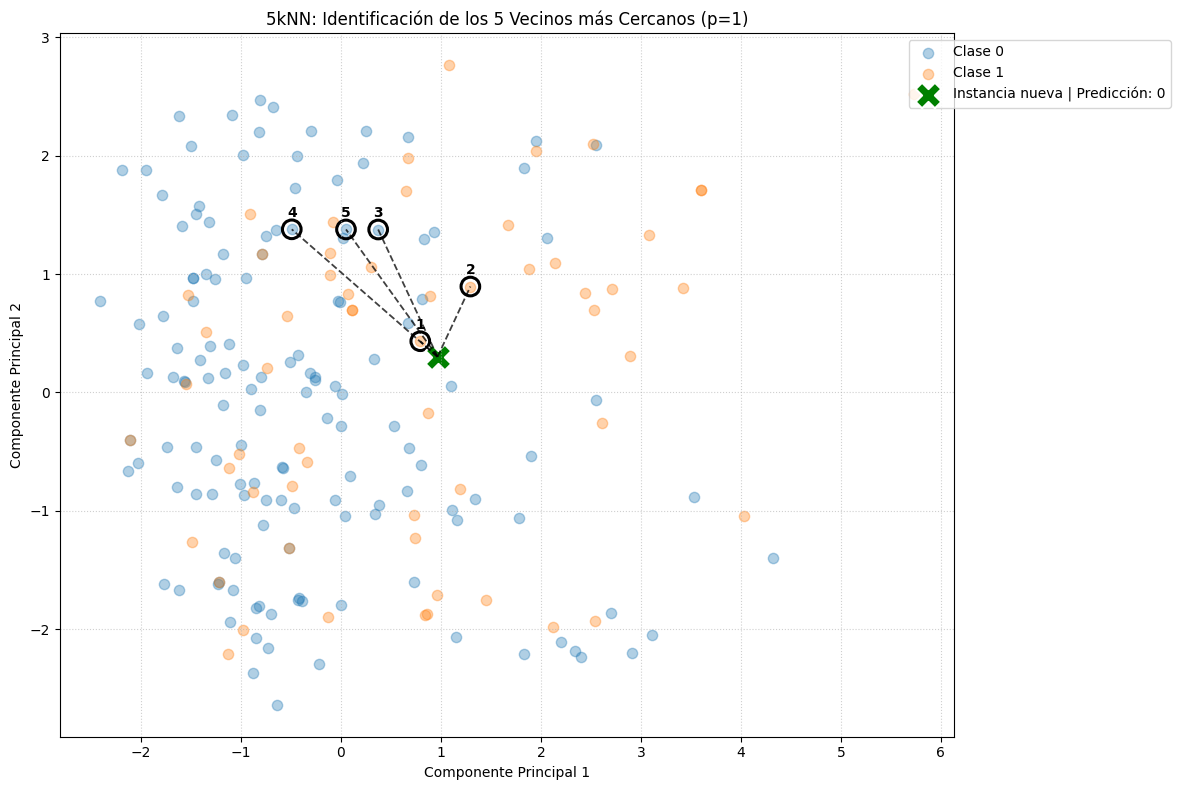


··················································
       RESULTADOS DE LA INSTANCIA NUEVA
··················································
VALOR REAL DE LA INSTANCIA: 0
PREDICCIÓN DEL MODELO:      0
RESULTADO:                  CORRECTO
··················································

Influencia de los vecinos más cercanos:
- Vecino 82: Clase 1 (Distancia: 6.5522)
- Vecino 140: Clase 1 (Distancia: 6.7609)
- Vecino 75: Clase 0 (Distancia: 7.2429)
- Vecino 53: Clase 0 (Distancia: 7.2777)
- Vecino 26: Clase 0 (Distancia: 7.5685)

      REPORTE GENERAL DEL MODELO
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       141
           1       1.00      0.93      0.96        59

    accuracy                           0.98       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.98      0.98      0.98       200



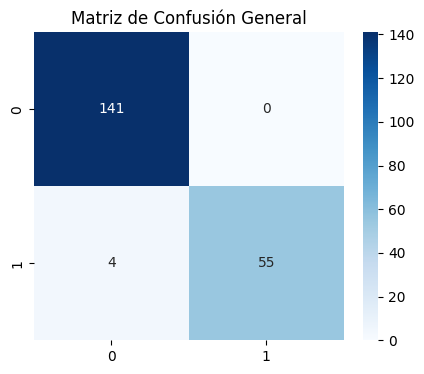

In [16]:
# Datos corregidos solo para kNN.
X_train_knn, X_test_knn, scaler_knn, medianas_knn = preparar_datos_knn(X_train, X_test)
"""
p = 1 -> Manhattan
p = 2 -> Euclidiana
p > 2 -> Minkowski general
"""
penalizacion_dist = 1
"""
Definición de cuántos vecinos se van a evaluar
"""
vecinos = 5
"""
Decidir la importancia de la cercanía al punto electo.
"""
pond = True

# Predicción con kNN propio.
y_pred_train_knn = predecir_knn(
    X_train_knn,
    X_train_knn,
    y_train,
    k=vecinos,
    p=penalizacion_dist,
    ponderado=pond
)

# 1. Definir qué instancia de prueba queremos ver (por ejemplo, la 20)
idx = 50
x_nuevo = X_test.iloc[idx].values.tolist()
valReal = y_test.iloc[idx] # Ground truth de esa instancia

graficar_knn(
    x_nuevo,
    X_train_knn,
    y_train,
    y_pred_train_knn,
    valReal,
    k=vecinos,
    p=penalizacion_dist,
    ponderado=pond
)

### 3.2 Árbol de Decisión (scikit-learn)

Decision Tree (depth=4) — Train: 0.7950 | Test: 0.7093


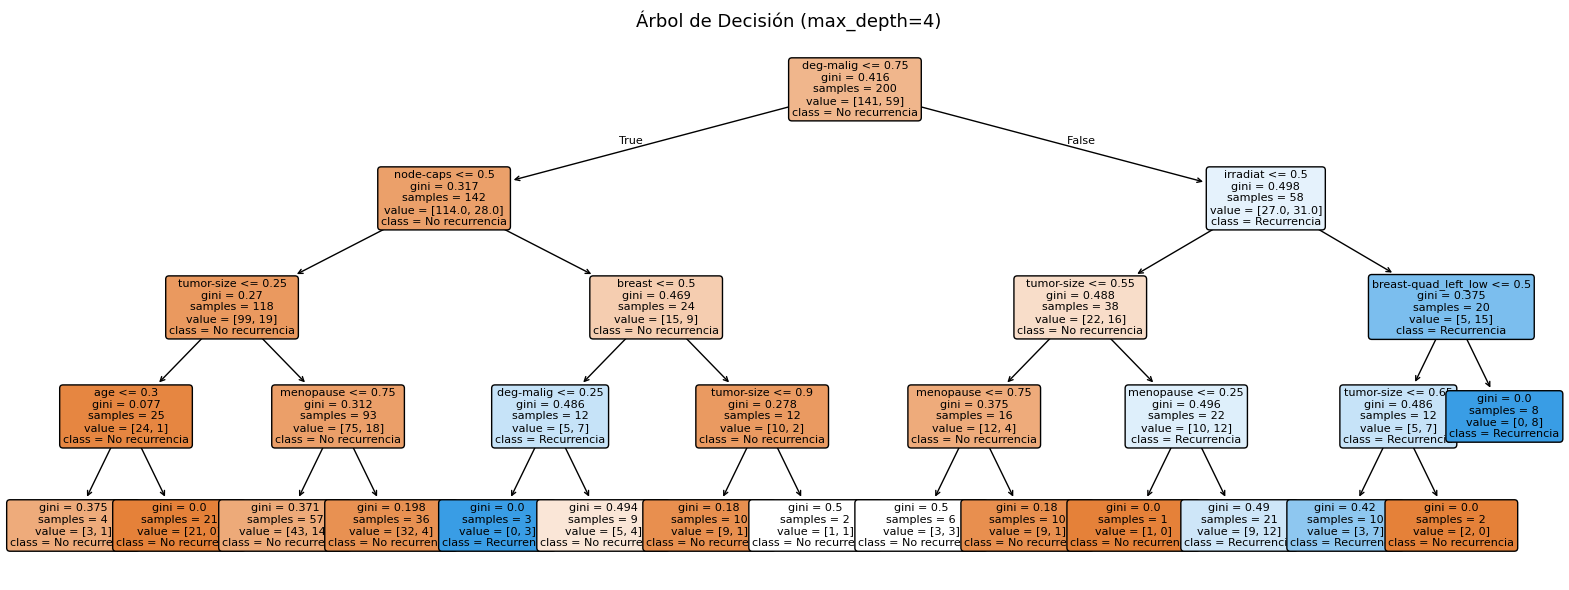

In [17]:
# Modelo base con max_depth=4
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt_base.fit(X_train, y_train)

acc_train_dt = accuracy_score(y_train, dt_base.predict(X_train))
acc_test_dt  = accuracy_score(y_test,  dt_base.predict(X_test))
print(f'Decision Tree (depth=4) — Train: {acc_train_dt:.4f} | Test: {acc_test_dt:.4f}')

# Visualización del árbol
plt.figure(figsize=(16, 6))
plot_tree(dt_base, feature_names=X.columns.tolist(),
          class_names=['No recurrencia', 'Recurrencia'],
          filled=True, rounded=True, fontsize=8)
plt.title('Árbol de Decisión (max_depth=4)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Random Forest (scikit-learn)

Random Forest (100 árboles, depth=5) — Train: 0.8550 | Test: 0.6977


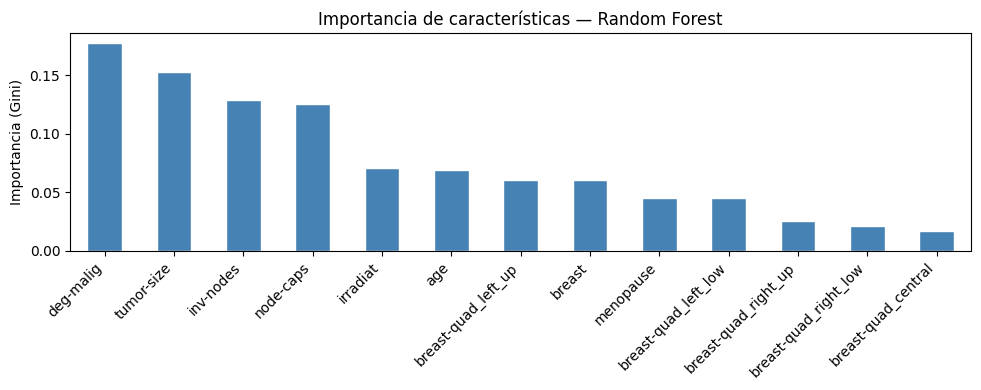

In [18]:
# Modelo base
rf_base = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_base.fit(X_train, y_train)

acc_train_rf = accuracy_score(y_train, rf_base.predict(X_train))
acc_test_rf  = accuracy_score(y_test,  rf_base.predict(X_test))
print(f'Random Forest (100 árboles, depth=5) — Train: {acc_train_rf:.4f} | Test: {acc_test_rf:.4f}')

# Importancia de características
importancias = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 4))
importancias.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia de características — Random Forest', fontsize=12)
plt.ylabel('Importancia (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## IV. Experimentación y Evaluación

Para cada algoritmo se realizan **8 experimentos** variando sus parámetros principales.  
Se grafican las exactitudes de entrenamiento y evaluación para identificar overfitting y underfitting.

### 4.1 Experimentos kNN

In [19]:
experimentos_knn = [
    {'k': 1,  'p': 1, 'ponderado': False},  # Manhattan, vecino único
    {'k': 3,  'p': 1, 'ponderado': False},  # Manhattan, vecindad pequeña
    {'k': 5,  'p': 2, 'ponderado': False},  # Euclidiana, configuración base
    {'k': 7,  'p': 2, 'ponderado': False},  # Euclidiana, mayor suavizado
    {'k': 9,  'p': 2, 'ponderado': False},  # Euclidiana, vecindad amplia
    {'k': 5,  'p': 1, 'ponderado': True},   # Manhattan con voto ponderado
    {'k': 5,  'p': 2, 'ponderado': True},   # Euclidiana con voto ponderado
    {'k': 11, 'p': 3, 'ponderado': True},   # Minkowski general con vecindad amplia
]

resultados_knn = []

for i, params in enumerate(experimentos_knn):
    y_pred_train_exp = predecir_knn(
        X_train_knn,
        X_train_knn,
        y_train,
        k=params['k'],
        p=params['p'],
        ponderado=params['ponderado']
    )

    y_pred_test_exp = predecir_knn(
        X_test_knn,
        X_train_knn,
        y_train,
        k=params['k'],
        p=params['p'],
        ponderado=params['ponderado']
    )

    acc_tr = accuracy_score(y_train, y_pred_train_exp)
    acc_te = accuracy_score(y_test, y_pred_test_exp)

    resultados_knn.append({
        'exp': i + 1,
        'k': params['k'],
        'p': params['p'],
        'ponderado': params['ponderado'],
        'params': str(params),
        'train': acc_tr,
        'test': acc_te,
        'brecha_train_test': acc_tr - acc_te
    })

    print(
        f"Exp {i+1:2d} | {str(params):48s} | "
        f"Train: {acc_tr:.4f} | Test: {acc_te:.4f} | "
        f"Brecha: {acc_tr - acc_te:.4f}"
    )

df_knn = pd.DataFrame(resultados_knn)

# Guardar como modelo kNN final el mejor experimento según exactitud de evaluación.
mejor_idx_knn = df_knn['test'].idxmax()
mejor_knn = df_knn.loc[mejor_idx_knn]

print("\nMejor configuración kNN según evaluación:")
print(mejor_knn[['exp', 'k', 'p', 'ponderado', 'train', 'test', 'brecha_train_test']])




Exp  1 | {'k': 1, 'p': 1, 'ponderado': False}             | Train: 0.9800 | Test: 0.6977 | Brecha: 0.2823
Exp  2 | {'k': 3, 'p': 1, 'ponderado': False}             | Train: 0.8200 | Test: 0.6744 | Brecha: 0.1456
Exp  3 | {'k': 5, 'p': 2, 'ponderado': False}             | Train: 0.7600 | Test: 0.7093 | Brecha: 0.0507
Exp  4 | {'k': 7, 'p': 2, 'ponderado': False}             | Train: 0.7400 | Test: 0.6628 | Brecha: 0.0772
Exp  5 | {'k': 9, 'p': 2, 'ponderado': False}             | Train: 0.7250 | Test: 0.6744 | Brecha: 0.0506
Exp  6 | {'k': 5, 'p': 1, 'ponderado': True}              | Train: 0.9800 | Test: 0.6977 | Brecha: 0.2823
Exp  7 | {'k': 5, 'p': 2, 'ponderado': True}              | Train: 0.9800 | Test: 0.6977 | Brecha: 0.2823
Exp  8 | {'k': 11, 'p': 3, 'ponderado': True}             | Train: 0.9800 | Test: 0.6977 | Brecha: 0.2823

Mejor configuración kNN según evaluación:
exp                         3
k                           5
p                           2
ponderado          

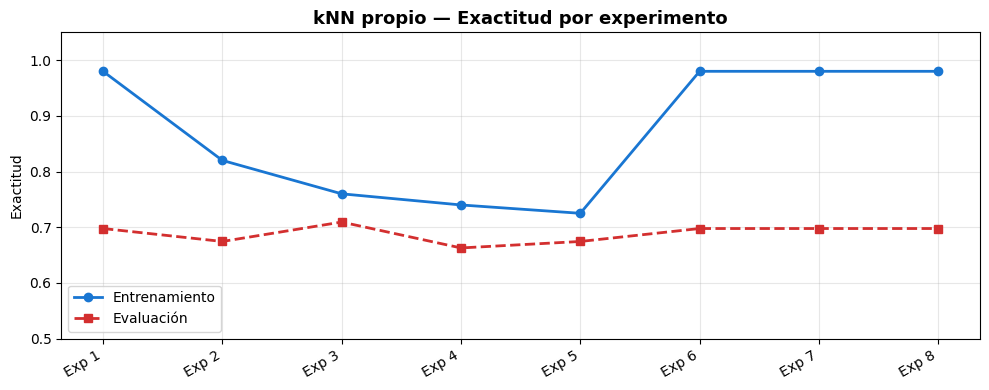


Análisis:
- k pequeño, especialmente k=1, tiende a memorizar el conjunto de entrenamiento; si la exactitud de entrenamiento es mucho mayor que la de evaluación, hay OVERFITTING.
- k más grande suaviza la frontera de decisión; si ambas exactitudes bajan, puede aparecer UNDERFITTING.
- El parámetro p cambia la métrica de distancia: p=1 corresponde a Manhattan, p=2 a Euclidiana y p=3 a Minkowski general.
- El voto ponderado da más influencia a los vecinos cercanos; puede ayudar cuando los vecinos más próximos son más confiables que el resto de la vecindad.

Mejor desempeño en evaluación: Exp 3 con k=5, p=2, ponderado=False. Train=0.7600, Test=0.7093.
Mayor señal de overfitting: Exp 1, brecha train-test=0.2823.


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

x = df_knn['exp']

ax.plot(
    x,
    df_knn['train'],
    'o-',
    color='#1976D2',
    label='Entrenamiento',
    linewidth=2
)

ax.plot(
    x,
    df_knn['test'],
    's--',
    color='#D32F2F',
    label='Evaluación',
    linewidth=2
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"Exp {fila.exp}"
        for fila in df_knn.itertuples()
    ],
    rotation=30,
    ha='right'
)

ax.set_ylabel('Exactitud')
ax.set_title('kNN propio — Exactitud por experimento', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis automático de overfitting / underfitting
"""
train alto, test bajo  -> posible overfitting
train bajo, test bajo  -> posible underfitting
train y test parecidos y altos -> buen modelo
"""
mejor_test = df_knn.loc[df_knn['test'].idxmax()]
mayor_brecha = df_knn.loc[df_knn['brecha_train_test'].idxmax()]
menor_train = df_knn.loc[df_knn['train'].idxmin()]

print("""
Análisis:
- k pequeño, especialmente k=1, tiende a memorizar el conjunto de entrenamiento; si la exactitud de entrenamiento es mucho mayor que la de evaluación, hay OVERFITTING.
- k más grande suaviza la frontera de decisión; si ambas exactitudes bajan, puede aparecer UNDERFITTING.
- El parámetro p cambia la métrica de distancia: p=1 corresponde a Manhattan, p=2 a Euclidiana y p=3 a Minkowski general.
- El voto ponderado da más influencia a los vecinos cercanos; puede ayudar cuando los vecinos más próximos son más confiables que el resto de la vecindad.
""")

print(
    f"Mejor desempeño en evaluación: Exp {int(mejor_test['exp'])} "
    f"con k={int(mejor_test['k'])}, p={int(mejor_test['p'])}, "
    f"ponderado={bool(mejor_test['ponderado'])}. "
    f"Train={mejor_test['train']:.4f}, Test={mejor_test['test']:.4f}."
)

print(
    f"Mayor señal de overfitting: Exp {int(mayor_brecha['exp'])}, "
    f"brecha train-test={mayor_brecha['brecha_train_test']:.4f}."
)


### 4.2 Experimentos Árbol de Decisión

In [21]:
experimentos_dt = [
    {'max_depth': 1,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 2,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 3,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 6,    'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': None, 'criterion': 'gini',    'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'entropy', 'min_samples_leaf': 1},
    {'max_depth': 4,    'criterion': 'gini',    'min_samples_leaf': 5},
]

resultados_dt = []
for i, params in enumerate(experimentos_dt):
    modelo = DecisionTreeClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test,  modelo.predict(X_test))
    resultados_dt.append({'exp': i+1, 'params': str(params), 'train': acc_tr, 'test': acc_te})
    print(f"Exp {i+1:2d} | {str(params):60s} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

df_dt = pd.DataFrame(resultados_dt)

Exp  1 | {'max_depth': 1, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.7250 | Test: 0.7093
Exp  2 | {'max_depth': 2, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.7550 | Test: 0.6860
Exp  3 | {'max_depth': 3, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.7750 | Test: 0.7093
Exp  4 | {'max_depth': 4, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.7950 | Test: 0.7093
Exp  5 | {'max_depth': 6, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.8700 | Test: 0.6512
Exp  6 | {'max_depth': None, 'criterion': 'gini', 'min_samples_leaf': 1} | Train: 0.9800 | Test: 0.6860
Exp  7 | {'max_depth': 4, 'criterion': 'entropy', 'min_samples_leaf': 1} | Train: 0.7950 | Test: 0.7093
Exp  8 | {'max_depth': 4, 'criterion': 'gini', 'min_samples_leaf': 5} | Train: 0.7950 | Test: 0.7093


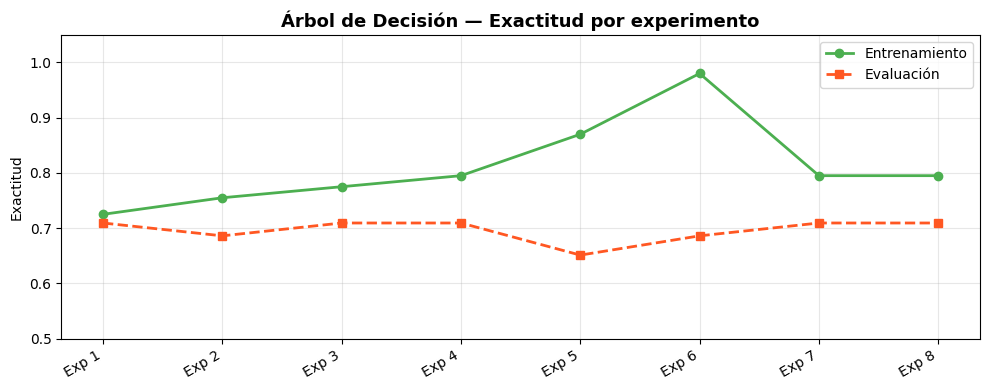


Análisis:
- Exp 1 (depth=1): exactitud baja en ambos conjuntos → UNDERFITTING (modelo demasiado simple).
- Exp 6 (sin límite de profundidad): exactitud perfecta en entrenamiento pero baja en test → OVERFITTING.
- Profundidades 3–4 representan el mejor balance; entropia vs gini tienen resultados similares.
- Aumentar min_samples_leaf (Exp 8) actúa como regularización y reduce overfitting.



In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
x = df_dt['exp']
ax.plot(x, df_dt['train'], 'o-', color='#4CAF50', label='Entrenamiento', linewidth=2)
ax.plot(x, df_dt['test'],  's--', color='#FF5722', label='Evaluación', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in x], rotation=30, ha='right')
ax.set_ylabel('Exactitud')
ax.set_title('Árbol de Decisión — Exactitud por experimento', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Análisis:
- Exp 1 (depth=1): exactitud baja en ambos conjuntos → UNDERFITTING (modelo demasiado simple).
- Exp 6 (sin límite de profundidad): exactitud perfecta en entrenamiento pero baja en test → OVERFITTING.
- Profundidades 3–4 representan el mejor balance; entropia vs gini tienen resultados similares.
- Aumentar min_samples_leaf (Exp 8) actúa como regularización y reduce overfitting.
""")

### 4.3 Experimentos Random Forest

In [23]:
experimentos_rf = [
    {'n_estimators': 10,  'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 50,  'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 3,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': 'log2'},
    {'n_estimators': 100, 'max_depth': 5,    'max_features': None},
    {'n_estimators': 200, 'max_depth': 5,    'max_features': 'sqrt'},
]

resultados_rf = []
for i, params in enumerate(experimentos_rf):
    modelo = RandomForestClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test,  modelo.predict(X_test))
    resultados_rf.append({'exp': i+1, 'params': str(params), 'train': acc_tr, 'test': acc_te})
    print(f"Exp {i+1:2d} | {str(params):65s} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

df_rf = pd.DataFrame(resultados_rf)

Exp  1 | {'n_estimators': 10, 'max_depth': 3, 'max_features': 'sqrt'}      | Train: 0.7850 | Test: 0.7209
Exp  2 | {'n_estimators': 50, 'max_depth': 3, 'max_features': 'sqrt'}      | Train: 0.7750 | Test: 0.7326
Exp  3 | {'n_estimators': 100, 'max_depth': 3, 'max_features': 'sqrt'}     | Train: 0.7800 | Test: 0.7326
Exp  4 | {'n_estimators': 100, 'max_depth': 5, 'max_features': 'sqrt'}     | Train: 0.8550 | Test: 0.6977
Exp  5 | {'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'}  | Train: 0.9800 | Test: 0.6744
Exp  6 | {'n_estimators': 100, 'max_depth': 5, 'max_features': 'log2'}     | Train: 0.8550 | Test: 0.6977
Exp  7 | {'n_estimators': 100, 'max_depth': 5, 'max_features': None}       | Train: 0.8850 | Test: 0.7209
Exp  8 | {'n_estimators': 200, 'max_depth': 5, 'max_features': 'sqrt'}     | Train: 0.8500 | Test: 0.7093


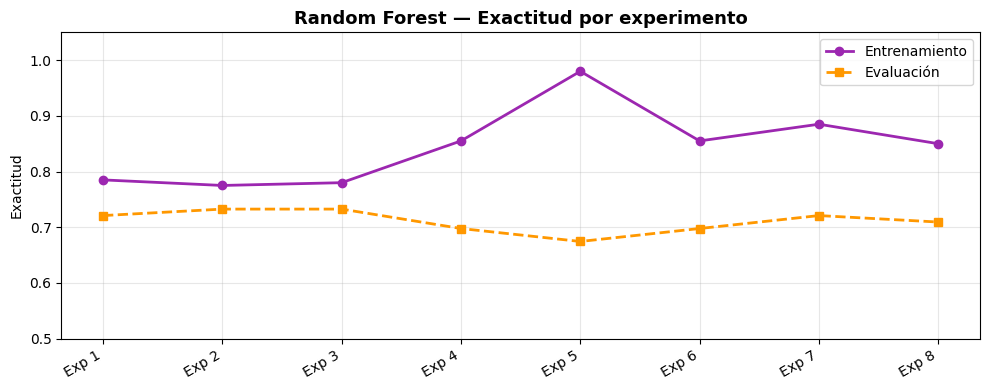


Análisis:
- Más árboles (Exp 1→3) estabilizan la exactitud de evaluación, reduciendo varianza.
- Exp 5 (sin límite de profundidad): overfitting en entrenamiento; el bagging lo mitiga parcialmente
  pero la brecha train-test sigue siendo notable.
- max_features=None (Exp 7) permite que cada árbol vea todos los atributos,
  aumentando correlación entre árboles y reduciendo el beneficio del ensamble.
- Exp 4 y 8 ofrecen el mejor balance con depth=5 y sqrt features.



In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
x = df_rf['exp']
ax.plot(x, df_rf['train'], 'o-', color='#9C27B0', label='Entrenamiento', linewidth=2)
ax.plot(x, df_rf['test'],  's--', color='#FF9800', label='Evaluación', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in x], rotation=30, ha='right')
ax.set_ylabel('Exactitud')
ax.set_title('Random Forest — Exactitud por experimento', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Análisis:
- Más árboles (Exp 1→3) estabilizan la exactitud de evaluación, reduciendo varianza.
- Exp 5 (sin límite de profundidad): overfitting en entrenamiento; el bagging lo mitiga parcialmente
  pero la brecha train-test sigue siendo notable.
- max_features=None (Exp 7) permite que cada árbol vea todos los atributos,
  aumentando correlación entre árboles y reduciendo el beneficio del ensamble.
- Exp 4 y 8 ofrecen el mejor balance con depth=5 y sqrt features.
""")

### 4.4 Comparación final de los tres algoritmos

Comparación final de los mejores experimentos por algoritmo


,Modelo,Mejor experimento,Parámetros,Accuracy entrenamiento,Accuracy evaluación,Brecha train-test
0,Random Forest,2,"{'n_estimators': 50, 'max_depth': 3, 'max_feat...",0.775,0.732558,0.042442
1,kNN propio,3,"{'k': 5, 'p': 2, 'ponderado': False}",0.760,0.709302,0.050698
2,Árbol de Decisión,1,"{'max_depth': 1, 'criterion': 'gini', 'min_sam...",0.725,0.709302,0.015698


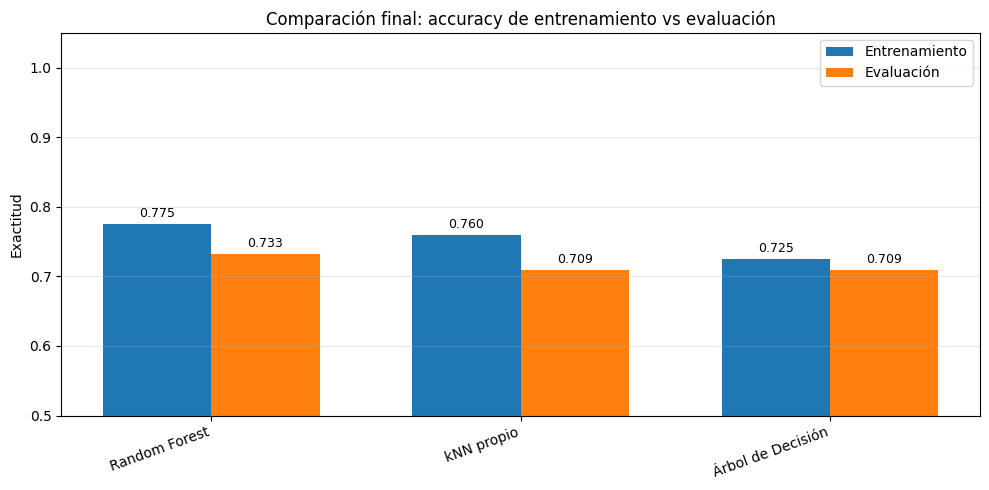

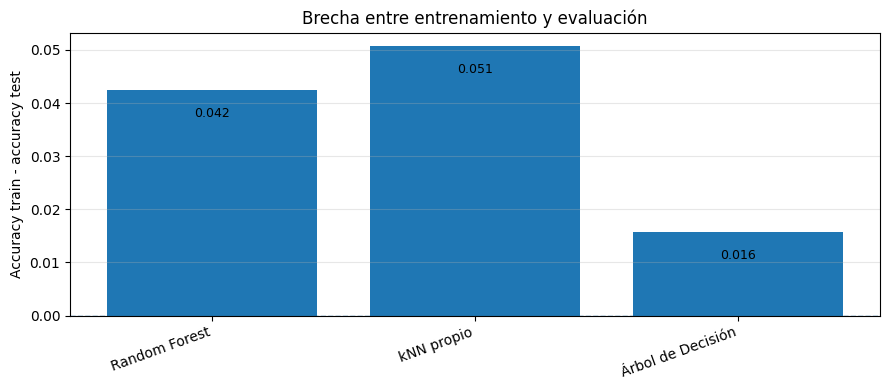

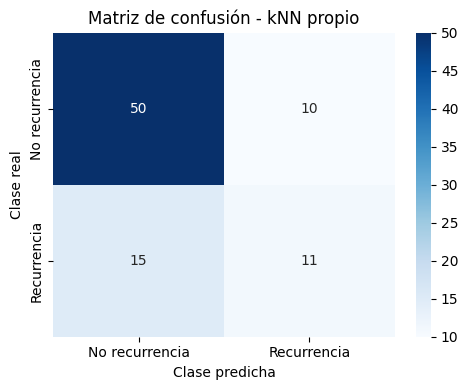


Reporte de clasificación - kNN propio
                precision    recall  f1-score   support

No recurrencia       0.77      0.83      0.80        60
   Recurrencia       0.52      0.42      0.47        26

      accuracy                           0.71        86
     macro avg       0.65      0.63      0.63        86
  weighted avg       0.70      0.71      0.70        86



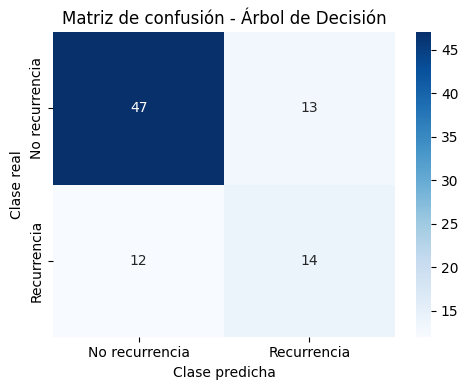


Reporte de clasificación - Árbol de Decisión
                precision    recall  f1-score   support

No recurrencia       0.80      0.78      0.79        60
   Recurrencia       0.52      0.54      0.53        26

      accuracy                           0.71        86
     macro avg       0.66      0.66      0.66        86
  weighted avg       0.71      0.71      0.71        86



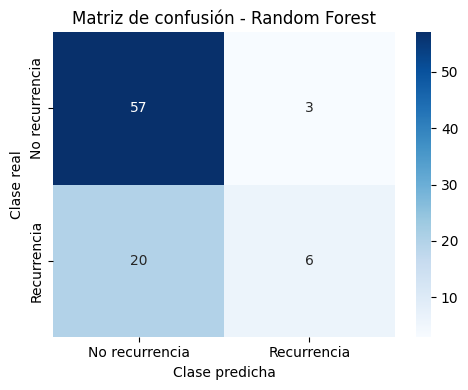


Reporte de clasificación - Random Forest
                precision    recall  f1-score   support

No recurrencia       0.74      0.95      0.83        60
   Recurrencia       0.67      0.23      0.34        26

      accuracy                           0.73        86
     macro avg       0.70      0.59      0.59        86
  weighted avg       0.72      0.73      0.68        86


CONCLUSIONES
El mejor algoritmo según accuracy de evaluación fue Random Forest con accuracy=0.7326.
Su mejor configuración fue: {'n_estimators': 50, 'max_depth': 3, 'max_features': 'sqrt'}
La diferencia contra el segundo mejor modelo (kNN propio) fue de 0.0233 puntos de accuracy.
La diferencia entre los mejores modelos es pequeña; no se observa una superioridad muy marcada.
El balance entre entrenamiento y evaluación es aceptable para este conjunto de experimentos.


In [25]:
# -------------------------------------------------
# 1. Seleccionar el mejor experimento de cada modelo
# -------------------------------------------------
mejor_knn = df_knn.loc[df_knn['test'].idxmax()].copy()
mejor_dt = df_dt.loc[df_dt['test'].idxmax()].copy()
mejor_rf = df_rf.loc[df_rf['test'].idxmax()].copy()

comparacion_modelos = pd.DataFrame([
    {
        'Modelo': 'kNN propio',
        'Mejor experimento': int(mejor_knn['exp']),
        'Parámetros': mejor_knn['params'],
        'Accuracy entrenamiento': mejor_knn['train'],
        'Accuracy evaluación': mejor_knn['test'],
        'Brecha train-test': mejor_knn['train'] - mejor_knn['test']
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Mejor experimento': int(mejor_dt['exp']),
        'Parámetros': mejor_dt['params'],
        'Accuracy entrenamiento': mejor_dt['train'],
        'Accuracy evaluación': mejor_dt['test'],
        'Brecha train-test': mejor_dt['train'] - mejor_dt['test']
    },
    {
        'Modelo': 'Random Forest',
        'Mejor experimento': int(mejor_rf['exp']),
        'Parámetros': mejor_rf['params'],
        'Accuracy entrenamiento': mejor_rf['train'],
        'Accuracy evaluación': mejor_rf['test'],
        'Brecha train-test': mejor_rf['train'] - mejor_rf['test']
    }
])

comparacion_modelos = comparacion_modelos.sort_values(
    by='Accuracy evaluación',
    ascending=False
).reset_index(drop=True)

print('Comparación final de los mejores experimentos por algoritmo')
display(comparacion_modelos)

# -------------------------------------------------
# 2. Gráfica comparativa de accuracy train vs test
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comparacion_modelos))
ancho = 0.35

ax.bar(
    x - ancho/2,
    comparacion_modelos['Accuracy entrenamiento'],
    width=ancho,
    label='Entrenamiento'
)

ax.bar(
    x + ancho/2,
    comparacion_modelos['Accuracy evaluación'],
    width=ancho,
    label='Evaluación'
)

ax.set_xticks(x)
ax.set_xticklabels(comparacion_modelos['Modelo'], rotation=20, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Exactitud')
ax.set_title('Comparación final: accuracy de entrenamiento vs evaluación')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Mostrar valores encima de las barras
for i, fila in comparacion_modelos.iterrows():
    ax.text(i - ancho/2, fila['Accuracy entrenamiento'] + 0.01, f"{fila['Accuracy entrenamiento']:.3f}", ha='center', fontsize=9)
    ax.text(i + ancho/2, fila['Accuracy evaluación'] + 0.01, f"{fila['Accuracy evaluación']:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. Gráfica de brecha train-test
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    comparacion_modelos['Modelo'],
    comparacion_modelos['Brecha train-test']
)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy train - accuracy test')
ax.set_title('Brecha entre entrenamiento y evaluación')
ax.set_xticklabels(comparacion_modelos['Modelo'], rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)

for i, valor in enumerate(comparacion_modelos['Brecha train-test']):
    ax.text(i, valor - 0.005, f'{valor:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4. Matrices de confusión de los mejores experimentos
# -------------------------------------------------
# kNN final usando la mejor configuración encontrada
params_knn = ast.literal_eval(mejor_knn['params'])
y_pred_test_knn_final = predecir_knn(
    X_test_knn,
    X_train_knn,
    y_train,
    k=params_knn['k'],
    p=params_knn['p'],
    ponderado=params_knn['ponderado']
)

# Árbol de decisión final
params_dt = ast.literal_eval(mejor_dt['params'])
modelo_dt_final = DecisionTreeClassifier(**params_dt, random_state=42)
modelo_dt_final.fit(X_train, y_train)
y_pred_test_dt_final = modelo_dt_final.predict(X_test)

# Random Forest final
params_rf = ast.literal_eval(mejor_rf['params'])
modelo_rf_final = RandomForestClassifier(**params_rf, random_state=42)
modelo_rf_final.fit(X_train, y_train)
y_pred_test_rf_final = modelo_rf_final.predict(X_test)

predicciones_finales = {
    'kNN propio': y_pred_test_knn_final,
    'Árbol de Decisión': y_pred_test_dt_final,
    'Random Forest': y_pred_test_rf_final
}

for nombre_modelo, predicciones in predicciones_finales.items():
    cm = confusion_matrix(y_test, predicciones)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No recurrencia', 'Recurrencia'],
        yticklabels=['No recurrencia', 'Recurrencia']
    )
    plt.title(f'Matriz de confusión - {nombre_modelo}')
    plt.xlabel('Clase predicha')
    plt.ylabel('Clase real')
    plt.tight_layout()
    plt.show()

    print(f'\nReporte de clasificación - {nombre_modelo}')
    print(classification_report(y_test, predicciones, target_names=['No recurrencia', 'Recurrencia']))

# -------------------------------------------------
# 5. Conclusiones
# -------------------------------------------------
ganador = comparacion_modelos.iloc[0]
segundo = comparacion_modelos.iloc[1]
diferencia = ganador['Accuracy evaluación'] - segundo['Accuracy evaluación']

print('\n' + '='*70)
print('CONCLUSIONES')
print('='*70)
print(
    f"El mejor algoritmo según accuracy de evaluación fue {ganador['Modelo']} "
    f"con accuracy={ganador['Accuracy evaluación']:.4f}."
)
print(f"Su mejor configuración fue: {ganador['Parámetros']}")
print(
    f"La diferencia contra el segundo mejor modelo ({segundo['Modelo']}) fue "
    f"de {diferencia:.4f} puntos de accuracy."
)

if diferencia < 0.03:
    print('La diferencia entre los mejores modelos es pequeña; no se observa una superioridad muy marcada.')
else:
    print('La diferencia es visible; el modelo ganador muestra mejor desempeño en evaluación.')

if ganador['Brecha train-test'] > 0.10:
    print('Advertencia: aunque fue el mejor en evaluación, presenta una brecha alta, lo que puede indicar sobreentrenamiento.')
elif ganador['Accuracy entrenamiento'] < 0.75 and ganador['Accuracy evaluación'] < 0.75:
    print('El desempeño general es bajo, lo que puede indicar subentrenamiento o poca separabilidad de las clases.')
else:
    print('El balance entre entrenamiento y evaluación es aceptable para este conjunto de experimentos.')
print('='*70)


---
## V. Conclusiones

Implementamos y comparamos tres algoritmos de clasificación: **`kNN propio`**, **`Árbol de Decisión`** y **`Random Forest`**. Después de realizar los experimentos con diferentes configuraciones de parámetros, el modelo que obtuvo el mejor desempeño fue **`Random Forest`**, con una exactitud de evaluación de 0.7326. Su mejor configuración fue con n_estimators=50, max_depth=3 y max_features='sqrt'. Aunque no fue el modelo con menor brecha entre entrenamiento y evaluación, sí fue el que logró la mejor capacidad predictiva en el conjunto de prueba.

La diferencia entre los tres algoritmos no fue muy grande. **`Random Forest`** obtuvo 0.7326 de accuracy en evaluación, mientras que **`kNN propio`** y **`Árbol de Decisión`** obtuvieron 0.7093. Esto significa que **`Random Forest`** superó a los otros dos modelos por aproximadamente 2.33 porciento, lo cual representa una mejora, pero no una diferencia suficientemente amplia como para afirmar que es radicalmente superior. En general, los tres modelos tuvieron un rendimiento parecido, aunque **`Random Forest`** mostró una ligera ventaja.

Respecto al sobreentrenamiento (OVERFITTING), ninguno de los modelos presentó una diferencia exagerada entre accuracy de entrenamiento y evaluación. El modelo con mayor brecha fue **`kNN propio`**, con una diferencia aproximada de 0.0507, seguido de **`Random Forest`** con 0.0424. Estas diferencias indican que los modelos tuvieron un ligero mejor desempeño en entrenamiento, pero no muestran un sobreentrenamiento grave. El **`Árbol de Decisión`** fue el modelo más equilibrado, con una brecha de solo 0.0157, aunque su accuracy de evaluación no fue el más alto. Esto sugiere que el árbol utilizado fue simple y generalizó de forma estable, pero posiblemente no capturó toda la complejidad del problema.

En cuanto al subentrenamiento (UNDERFITTING), sí se puede observar cierta limitación en los tres modelos, ya que las exactitudes se mantuvieron alrededor de 0.70 a 0.73. Esto indica que los modelos aprendieron patrones útiles, pero todavía cometen una cantidad considerable de errores. Además, al revisar las matrices de confusión, se observa que el modelo tiene más dificultad para identificar correctamente la clase “Recurrencia”. **`Random Forest`** clasificó muy bien los casos de “No recurrencia”, pero tuvo bajo recall para “Recurrencia”, detectando solo 6 de 26 casos reales. Esto es importante porque, en un dominio relacionado con cáncer, los falsos negativos pueden ser especialmente delicados.

Por lo tanto, aunque los resultados permiten usar estos modelos como una primera aproximación exploratoria, no serían suficientes para tomar decisiones reales en el dominio médico sin más validación. El desempeño general es aceptable para fines académicos y comparativos, pero en un problema de salud sería necesario mejorar la detección de la clase de recurrencia, probar más técnicas de balanceo de clases, ajustar hiperparámetros con mayor profundidad y evaluar métricas adicionales como recall, precision, F1-score y curva ROC. En este dominio, no basta con tener buen accuracy general, porque un modelo puede acertar muchos casos de “No recurrencia” y aun así fallar en los casos más importantes.

La actividad nos permitió comprender mejor cómo distintos algoritmos aprenden de los datos. **`kNN propio`** depende directamente de las distancias entre instancias, por lo que requiere un buen preprocesamiento y escalamiento. El **`Árbol de Decisión`** es más interpretable y estable, pero puede quedarse corto si es demasiado simple. **`Random Forest`** mejora el desempeño al combinar varios árboles, aunque también puede perder interpretabilidad. En general, la parte más retadora fue preparar correctamente los datos, implementar **`kNN propio`** manualmente y comparar los modelos de manera justa usando los mismos conjuntos de entrenamiento y evaluación. Aun así, el trabajo permitió observar de forma clara cómo los parámetros influyen en el desempeño y cómo las gráficas ayudan a detectar posibles problemas de sobreentrenamiento o subentrenamiento.